In [57]:
import SimpleITK as sitk 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

## AAL3

In [58]:
base_dir = Path(r'C:\Users\Notebook\Desktop\NeuroComp\tutorial\data')
subject_to_process = 'CP01182'
subject_to_process_31 = 'CP0031'
feat_output_subdir = '..feat'  
feat_output_subdir_31 = '.feat'  
atlas_output_subdir = 'atlas'
subject_dir = base_dir / subject_to_process
subject_dir_31 = base_dir / subject_to_process_31
feat_dir = subject_dir / feat_output_subdir
feat_dir_31 = subject_dir_31 / feat_output_subdir_31
atlas_dir =base_dir / atlas_output_subdir

filename_fmri_in_MNI152_space = feat_dir / 'fmri_in_mni152_space.nii.gz'
filename_fmri_in_MNI152_space_SUJETO31 = feat_dir / 'fmri_in_mni152_space_sujeto_31.nii.gz'
filename_AAL3 = atlas_dir / 'AAL3v1.nii.gz'

fmri_in_MNI152_space = sitk.ReadImage(str(filename_fmri_in_MNI152_space))
fmri_in_MNI152_space_31 = sitk.ReadImage(str(filename_fmri_in_MNI152_space_SUJETO31))
aal3 = sitk.ReadImage(str(filename_AAL3))


In [59]:

nda_fmri_in_MNI152_space = sitk.GetArrayFromImage(fmri_in_MNI152_space) # (z, t, y, x)
nda_fmri_in_MNI152_space = np.transpose(nda_fmri_in_MNI152_space, (2, 3, 1, 0)) # (y, x, t, z)
nda_fmri = np.reshape(nda_fmri_in_MNI152_space, (-1, nda_fmri_in_MNI152_space.shape[-1]))  # (n_voxels, t)

nda_fmri_in_MNI152_space_31 = sitk.GetArrayFromImage(fmri_in_MNI152_space_31) # (z, t, y, x)
nda_fmri_in_MNI152_space_31 = np.transpose(nda_fmri_in_MNI152_space_31, (2, 3, 1, 0)) # (y, x, t, z)
nda_fmri_31 = np.reshape(nda_fmri_in_MNI152_space_31, (-1, nda_fmri_in_MNI152_space_31.shape[-1]))  # (n_voxels, t)

nda_aal3 = sitk.GetArrayFromImage(aal3) # (z, y, x)
nda_aal3 = np.transpose(nda_aal3, (1, 2, 0)) # (y, x, z)
nda_aal3 = np.reshape(nda_aal3,-1)


In [60]:
region_labels = {}
with open(str(atlas_dir / 'AAL3v1.nii.txt'), 'r') as f:
    for line in f:
        if line.strip():  # evitar líneas vacías
            parts = line.strip().split()
            if len(parts) == 3:
                _, region_name, region_number = parts
                region_labels[int(region_number)] = region_name


In [61]:
# Obtener IDs de regiones presentes en el atlas
region_ids = np.unique(nda_aal3) # valores unicos
region_ids = region_ids[region_ids != 0]  # excluir fondo (todo el fondo es 0)

# Diccionario para almacenar las señales
bold_signals_by_region = {}
bold_signals_by_region_31 = {}

for region_id in region_ids:
    region_mask = nda_aal3 == region_id # region de la mascara tal que nda_aal3 == region_id
    # Crear una máscara booleana para la región
    region_timecourses = nda_fmri[region_mask, :]  # (n_voxels_in_region, time)
    region_timecourses_31 = nda_fmri_31[region_mask, :]  # (n_voxels_in_region, time)

    mean_signal = region_timecourses.mean(axis=0)  # (time,)
    mean_signal_31 = region_timecourses_31.mean(axis=0)  # (time,)
    
    region_name = region_labels.get(region_id, f'Region_{region_id}')
    bold_signals_by_region[region_name] = mean_signal
    bold_signals_by_region_31[region_name] = mean_signal_31


In [63]:
# Convertir a matriz (n_regiones, tiempo) como en tp1
region_names = list(bold_signals_by_region.keys())
bold_matrix = np.array([bold_signals_by_region[name] for name in region_names])

region_names_31 = list(bold_signals_by_region_31.keys())
bold_matrix_31 = np.array([bold_signals_by_region_31[name] for name in region_names_31])

# Normalizar cada señal (cada fila) con Z-score
bold_matrix_z = (bold_matrix - bold_matrix.mean(axis=1, keepdims=True)) / bold_matrix.std(axis=1, keepdims=True)

bold_matrix_z_31 = (bold_matrix_31 - bold_matrix_31.mean(axis=1, keepdims=True)) / bold_matrix_31.std(axis=1, keepdims=True)

bold_matrix_concat = np.concatenate((bold_matrix_z, bold_matrix_z_31), axis=1)

# Matriz de correlación entre señales normalizadas
correlation_matrix = np.corrcoef(bold_matrix_z)
correlation_matrix_31 = np.corrcoef(bold_matrix_z_31)
correlation_matrix_concat = np.corrcoef(bold_matrix_concat)



print('size bold_matrix :', bold_matrix.shape)
print('size bold_matrix_31 :', bold_matrix_31.shape)


size bold_matrix : (166, 200)
size bold_matrix_31 : (166, 140)


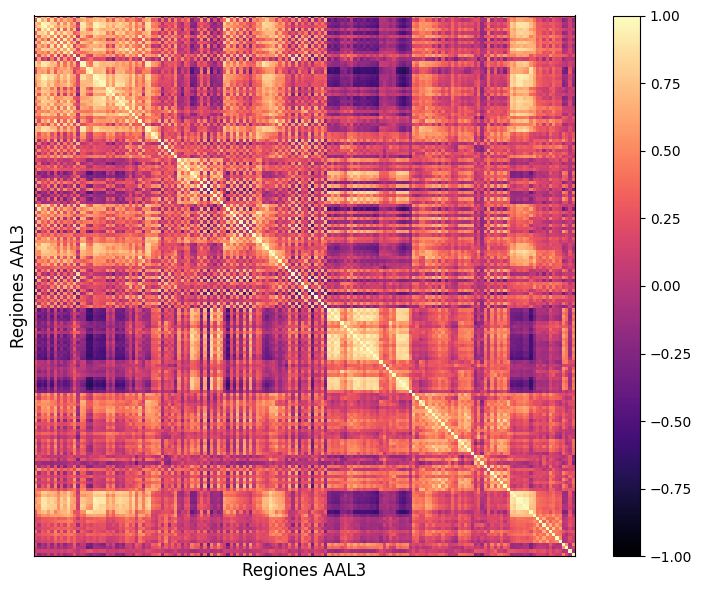

In [64]:
plt.figure(figsize=(8, 6))
im = plt.imshow(correlation_matrix, cmap='magma', vmin=-1, vmax=1)
#plt.title('Matriz de correlación entre señales BOLD', fontsize=14)
plt.colorbar(im)
#plt.xticks(ticks=np.arange(len(region_names)), labels=region_names, rotation=90, fontsize=6)
plt.xticks([])
plt.yticks([])
plt.xlabel('Regiones AAL3', fontsize=12)
plt.ylabel('Regiones AAL3', fontsize=12)
#plt.yticks(ticks=np.arange(len(region_names)), labels=region_names, fontsize=6)
plt.tight_layout()
plt.show()


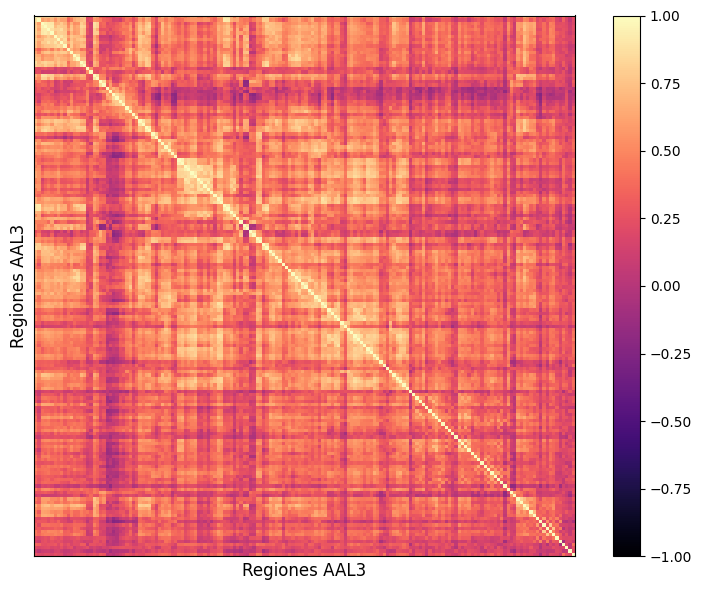

In [65]:
plt.figure(figsize=(8, 6))
im = plt.imshow(correlation_matrix_31, cmap='magma', vmin=-1, vmax=1)
#plt.title('Matriz de correlación entre señales BOLD', fontsize=14)
plt.colorbar(im)
#plt.xticks(ticks=np.arange(len(region_names)), labels=region_names, rotation=90, fontsize=6)
plt.xticks([])
plt.yticks([])
plt.xlabel('Regiones AAL3', fontsize=12)
plt.ylabel('Regiones AAL3', fontsize=12)
#plt.yticks(ticks=np.arange(len(region_names)), labels=region_names, fontsize=6)
plt.tight_layout()
plt.show()


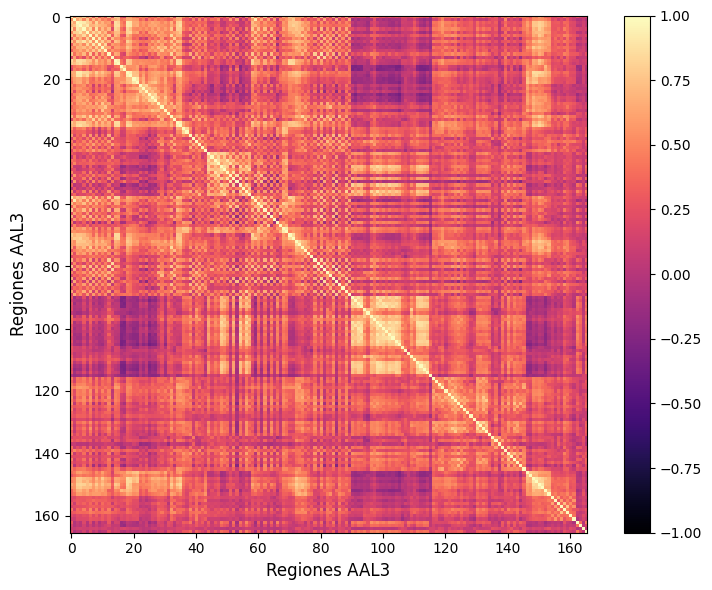

In [66]:

# Visualización
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
im = plt.imshow(correlation_matrix_concat, cmap='magma', vmin=-1, vmax=1)
#plt.title('Matriz de correlación funcional (sujetos concatenados)', fontsize=14)
plt.colorbar(im)



plt.xlabel('Regiones AAL3', fontsize=12)
plt.ylabel('Regiones AAL3', fontsize=12)
plt.tight_layout()
plt.show()


## Schaefer

In [67]:
import SimpleITK as sitk 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

In [69]:
base_dir = Path(r'C:\Users\Notebook\Desktop\NeuroComp\tutorial\data')
subject_to_process = 'CP01182'
feat_output_subdir = '..feat'  
atlas_output_subdir = 'atlas'
subject_dir = base_dir / subject_to_process
feat_dir = subject_dir / feat_output_subdir
atlas_dir =base_dir / atlas_output_subdir

filename_fmri_in_MNI152_space = feat_dir / 'fmri_in_mni152_space.nii.gz'
filename_fmri_in_MNI152_space_SUJETO31 = feat_dir / 'fmri_in_mni152_space_sujeto_31.nii.gz'
filename_SH = atlas_dir / 'Schaefer2018_1000Parcels_7Networks_order_FSLMNI152_2mm.nii.gz'

fmri_in_MNI152_space = sitk.ReadImage(str(filename_fmri_in_MNI152_space))
fmri_in_MNI152_space_31 = sitk.ReadImage(str(filename_fmri_in_MNI152_space_SUJETO31))
SH = sitk.ReadImage(str(filename_SH))



In [70]:

nda_fmri_in_MNI152_space = sitk.GetArrayFromImage(fmri_in_MNI152_space) # (z, t, y, x)
nda_fmri_in_MNI152_space_31 = sitk.GetArrayFromImage(fmri_in_MNI152_space_31) # (z, t, y, x)
nda_fmri_in_MNI152_space = np.transpose(nda_fmri_in_MNI152_space, (2, 3, 1, 0)) # (y, x, t, z)
nda_fmri_in_MNI152_space_31 = np.transpose(nda_fmri_in_MNI152_space_31, (2, 3, 1, 0)) # (y, x, t, z)
print("fMRI shape before reshape:", nda_fmri_in_MNI152_space.shape)
print("fMRI shape before reshape 31:", nda_fmri_in_MNI152_space_31.shape)
nda_fmri = nda_fmri_in_MNI152_space.reshape(-1, nda_fmri_in_MNI152_space.shape[-1])  # (n_voxels, t)
nda_fmri_31 = nda_fmri_in_MNI152_space_31.reshape(-1, nda_fmri_in_MNI152_space_31.shape[-1])  # (n_voxels, t)


nda_SH = sitk.GetArrayFromImage(SH) # (z, y, x)
nda_SH = np.transpose(nda_SH, (1, 2, 0)) # (y, x, z)


print("SH shape before reshape:", nda_SH.shape)


nda_SH = np.reshape(nda_SH,-1)

print("fMRI shape post reshape:", nda_fmri.shape)
print("SH shape post reshape:", nda_SH.shape)


fMRI shape before reshape: (109, 91, 91, 200)
fMRI shape before reshape 31: (109, 91, 91, 140)
SH shape before reshape: (109, 91, 91)
fMRI shape post reshape: (902629, 200)
SH shape post reshape: (902629,)


In [71]:
bold_signals_by_region = {}
bold_signals_by_region_31 = {}
unique_labels = np.unique(nda_SH)
unique_labels = unique_labels[unique_labels > 0]  # descartamos el 0 (fondo)

for label in unique_labels:
    # Indices de los voxeles que pertenecen a esta región
    region_mask = nda_SH == label

    # Extraer las señales BOLD correspondientes a esos vóxeles
    region_bold = nda_fmri[region_mask, :]
    region_bold_31 = nda_fmri_31[region_mask, :]  # (n_voxeles_in_region, time)

    # Promediar sobre los vóxeles → señal 1D por ROI
    mean_bold_signal = region_bold.mean(axis=0)
    mean_bold_signal_31 = region_bold_31.mean(axis=0)  # (time,)

    bold_signals_by_region[f'Region_{int(label)}'] = mean_bold_signal
    bold_signals_by_region_31[f'Region_{int(label)}'] = mean_bold_signal_31  # (time,)


In [72]:
# Convertir a matriz (n_regiones, tiempo) como en tp1
region_names = list(bold_signals_by_region.keys())
region_names_31 = list(bold_signals_by_region_31.keys())
bold_matrix = np.array([bold_signals_by_region[name] for name in region_names])
bold_matrix_31 = np.array([bold_signals_by_region_31[name] for name in region_names_31])

# Normalizar cada señal (cada fila) con Z-score
bold_matrix_z = (bold_matrix - bold_matrix.mean(axis=1, keepdims=True)) / bold_matrix.std(axis=1, keepdims=True)
bold_matrix_z_31 = (bold_matrix_31 - bold_matrix_31.mean(axis=1, keepdims=True)) / bold_matrix_31.std(axis=1, keepdims=True)
bold_matrix_concat = np.concatenate((bold_matrix_z, bold_matrix_z_31), axis=1)

# Matriz de correlación entre señales normalizadas
correlation_matrix = np.corrcoef(bold_matrix_z)
correlation_matrix_31 = np.corrcoef(bold_matrix_z_31)
correlation_matrix_concat = np.corrcoef(bold_matrix_concat)

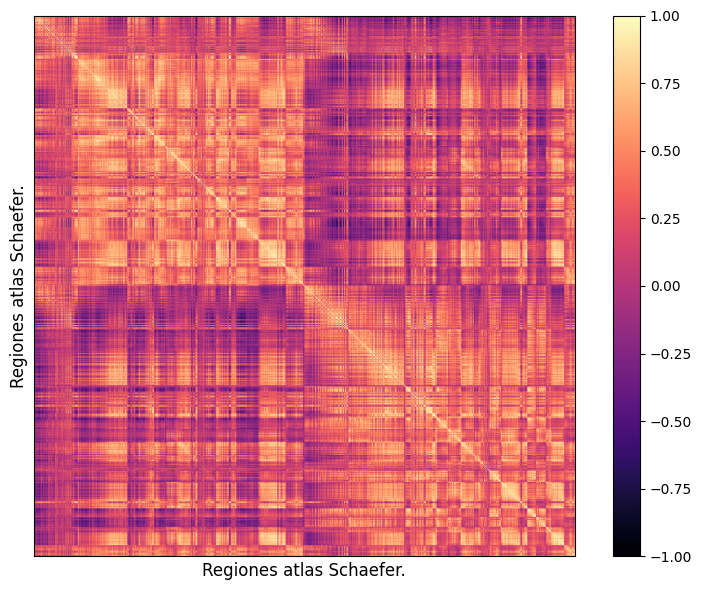

In [73]:

plt.figure(figsize=(8, 6))
im = plt.imshow(correlation_matrix, cmap='magma', vmin=-1, vmax=1)
#plt.title('Matriz de correlación entre señales BOLD normalizadas (atlas Schaefer.)', fontsize=14)
plt.colorbar(im)
#plt.xticks(ticks=np.arange(len(region_names)), labels=region_names, rotation=90, fontsize=6)
plt.xticks([])
plt.yticks([])
plt.xlabel('Regiones atlas Schaefer.', fontsize=12)
plt.ylabel('Regiones atlas Schaefer.', fontsize=12)
#plt.yticks(ticks=np.arange(len(region_names)), labels=region_names, fontsize=6)
plt.tight_layout()
plt.show()

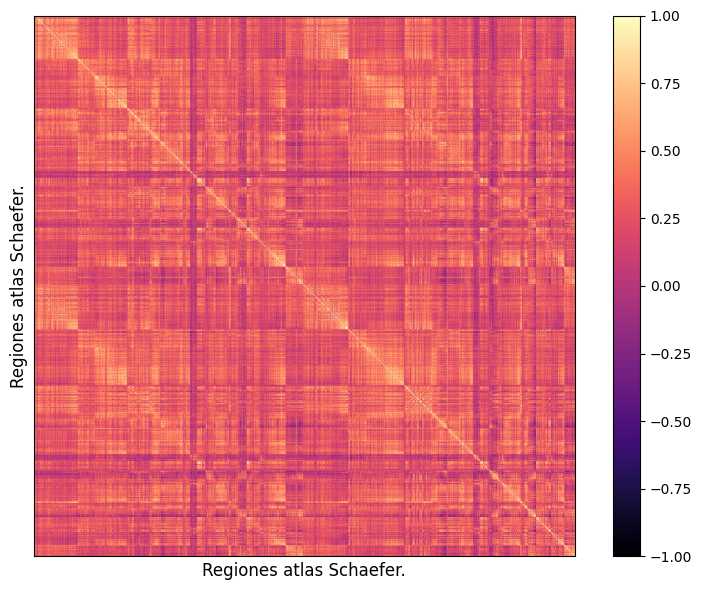

In [74]:
plt.figure(figsize=(8, 6))
im = plt.imshow(correlation_matrix_31, cmap='magma', vmin=-1, vmax=1)
#plt.title('Matriz de correlación entre señales BOLD normalizadas (atlas Schaefer.)', fontsize=14)
plt.colorbar(im)
#plt.xticks(ticks=np.arange(len(region_names)), labels=region_names, rotation=90, fontsize=6)
plt.xticks([])
plt.yticks([])
plt.xlabel('Regiones atlas Schaefer.', fontsize=12)
plt.ylabel('Regiones atlas Schaefer.', fontsize=12)
#plt.yticks(ticks=np.arange(len(region_names)), labels=region_names, fontsize=6)
plt.tight_layout()
plt.show()

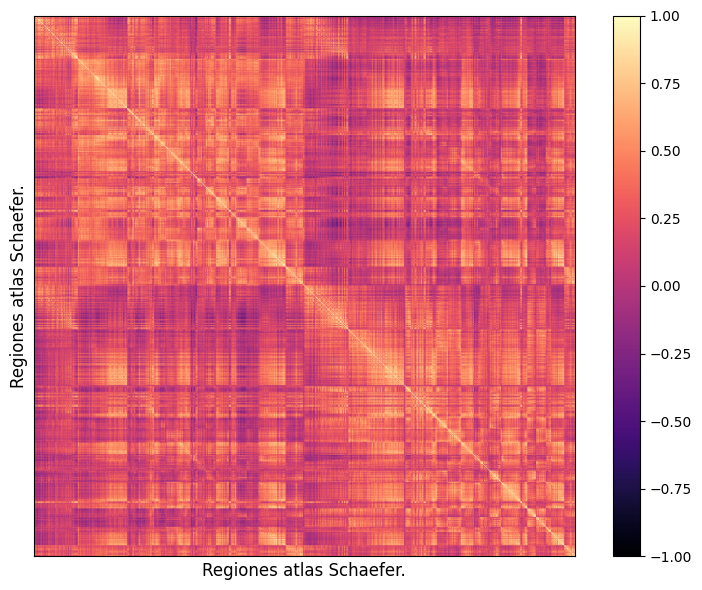

In [75]:
plt.figure(figsize=(8, 6))
im = plt.imshow(correlation_matrix_concat, cmap='magma', vmin=-1, vmax=1)
#plt.title('Matriz de correlación entre señales BOLD normalizadas (atlas Schaefer.)', fontsize=14)
plt.colorbar(im)
#plt.xticks(ticks=np.arange(len(region_names)), labels=region_names, rotation=90, fontsize=6)
plt.xticks([])
plt.yticks([])
plt.xlabel('Regiones atlas Schaefer.', fontsize=12)
plt.ylabel('Regiones atlas Schaefer.', fontsize=12)
#plt.yticks(ticks=np.arange(len(region_names)), labels=region_names, fontsize=6)
plt.tight_layout()
plt.show()